# 06 · Evaluación — Explicabilidad con SHAP

La importancia de variables dice *cuánto* pesa cada variable, pero no *en qué
dirección* ni *para quién*. **SHAP** (SHapley Additive exPlanations) responde eso.

## Idea teórica

SHAP viene de la **teoría de juegos cooperativos**: trata cada predicción como un
"premio" que hay que repartir de forma justa entre las variables (los "jugadores").
El **valor de Shapley** de una variable es su contribución marginal promediada sobre
todos los órdenes posibles en que se podrían ir incorporando las variables. Propiedad
clave — **aditividad local**:

$$f(x) = \phi_0 + \sum_{j} \phi_j(x)$$

la predicción de un caso = **valor base** $\phi_0$ (la predicción promedio del
modelo) **+ la suma de los aportes SHAP** $\phi_j$ de cada variable. Así cada
predicción individual queda completamente descompuesta.

## TreeSHAP

Para ensembles de árboles existe **TreeSHAP**, un algoritmo **exacto y rápido** que
explota la estructura de los árboles (no aproxima por muestreo). Para clasificación
binaria con XGBoost, los valores SHAP están en **espacio de log-odds (margin)**: un
aporte positivo empuja hacia churn=1.

Explicamos sobre el **test OOT** (fuera de muestra). Es un set chico (~800 filas):
los patrones globales son indicativos; para mayor estabilidad se puede explicar
sobre `X` completo cambiando `X_explain`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_test, y_test = X[test_mask], y[test_mask]

# --- cargar el modelo tuneado (o reconstruirlo desde los hiperparámetros) ---
model_path = base / "models" / "xgboost_tuned.joblib"
params_path = base / "05_modelling" / "xgboost_best_params.json"
if model_path.exists():
    model = joblib.load(model_path)
    print(f"modelo cargado: {model_path.relative_to(base)}")
else:
    if not params_path.exists():
        raise FileNotFoundError(
            "Falta el modelo. Corre primero 05_modelling/02_tuning_xgboost_optuna.ipynb "
            "(secciones 2 y 6) para generar models/xgboost_tuned.joblib.")
    best = json.load(open(params_path))["best_params"]
    spw = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()
    model = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X[train_mask], y[train_mask])
    print("modelo reconstruido desde hiperparámetros y entrenado en train OOT")

# El modelo está entrenado sobre el train OOT → lo explicamos/evaluamos sobre el
# test OOT (fuera de muestra). Para el modelo desplegado se reentrenaría con todo.
p_test = model.predict_proba(X_test)[:, 1]
print(f"test OOT: {test_mask.sum():,} filas | prevalencia churn {y_test.mean():.3f}")

modelo cargado: models/xgboost_tuned.joblib
test OOT: 885 filas | prevalencia churn 0.278


In [2]:
import shap

X_explain = X_test                       # cambia a `X` para una vista global más estable
explainer = shap.TreeExplainer(model)
sv = explainer(X_explain)                # objeto Explanation (valores en log-odds)
print(f"explicadas {sv.values.shape[0]:,} filas × {sv.values.shape[1]} variables")
print(f"valor base (log-odds): {float(np.ravel(sv.base_values)[0]):.4f}")

explicadas 885 filas × 71 variables
valor base (log-odds): 0.0040


## A · Importancia global SHAP

`beeswarm` muestra, por variable, la distribución de aportes SHAP coloreada por el
valor de la variable (rojo = alto, azul = bajo) → revela *dirección* y *no
linealidad*. `bar` resume el **|SHAP| promedio** (magnitud de influencia).

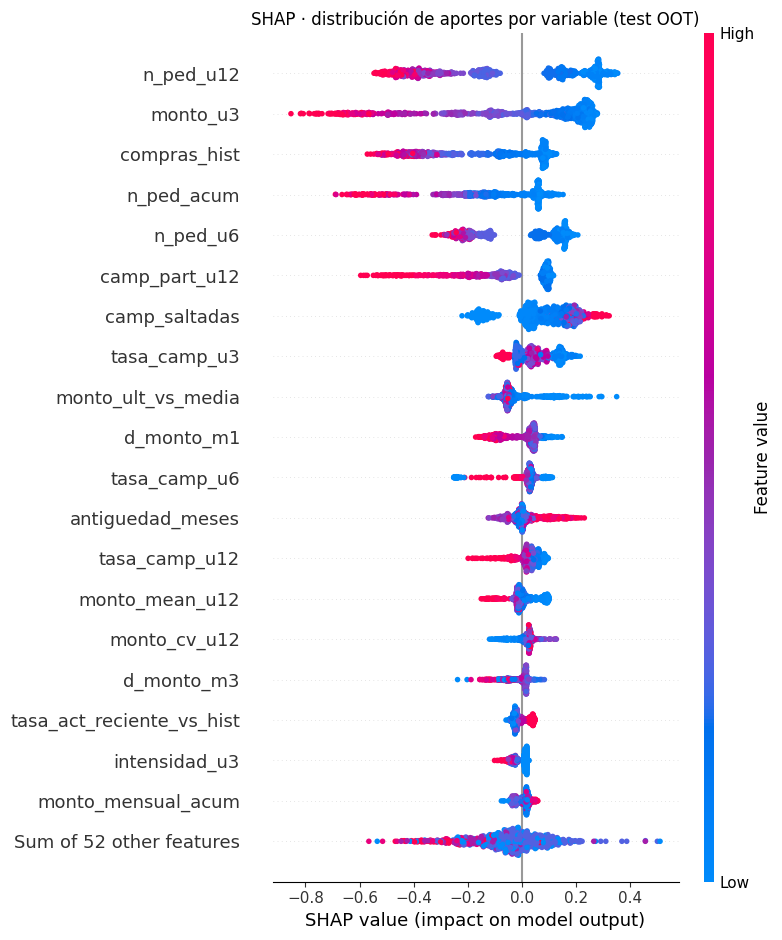

In [3]:
shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title("SHAP · distribución de aportes por variable (test OOT)")
plt.tight_layout(); plt.show()

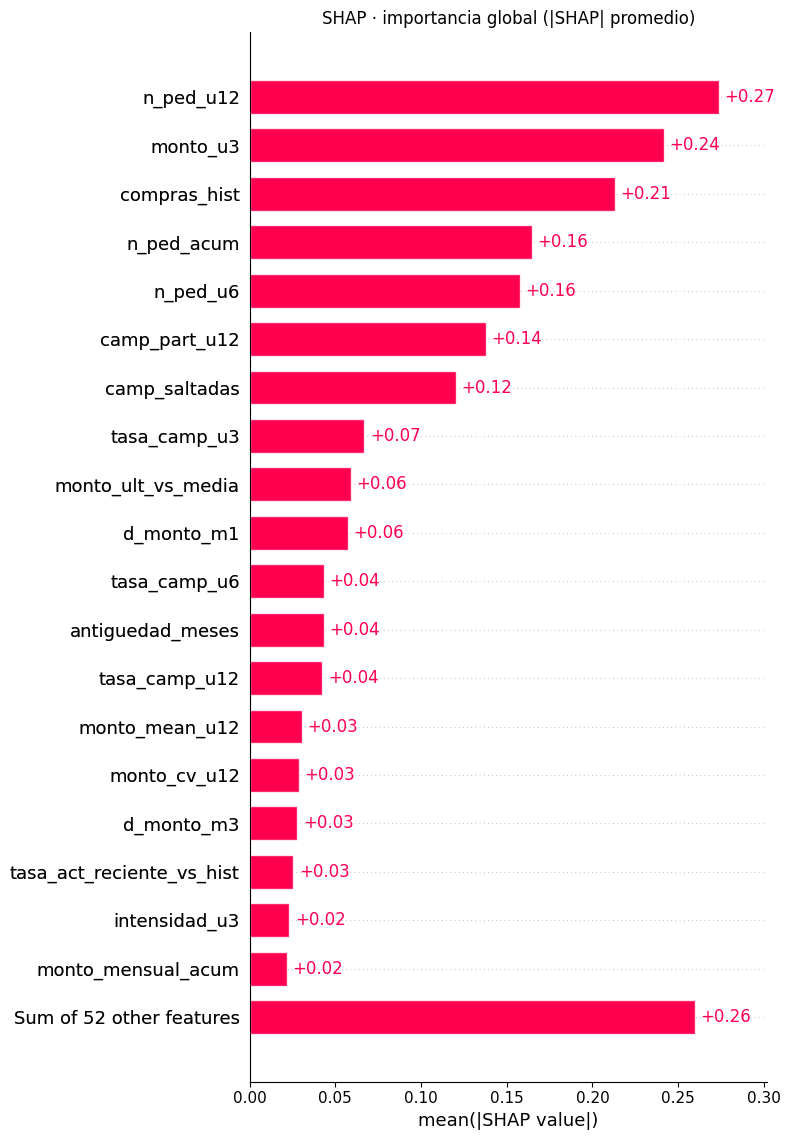

In [4]:
shap.plots.bar(sv, max_display=20, show=False)
plt.title("SHAP · importancia global (|SHAP| promedio)")
plt.tight_layout(); plt.show()

## B · Dependencia: forma del efecto

Para las variables más influyentes, `scatter` muestra el aporte SHAP frente al
valor de la variable → la *forma* del efecto (umbrales, saturación). El color
resalta la interacción más fuerte detectada automáticamente.

Top 3 por |SHAP| promedio: ['n_ped_u12', 'monto_u3', 'compras_hist']


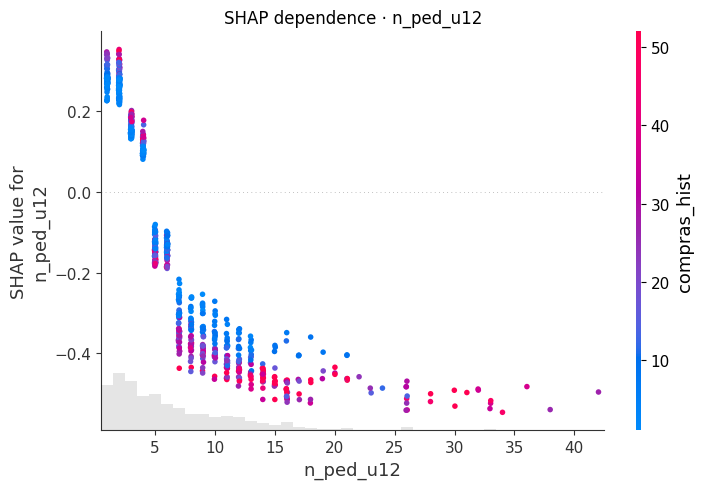

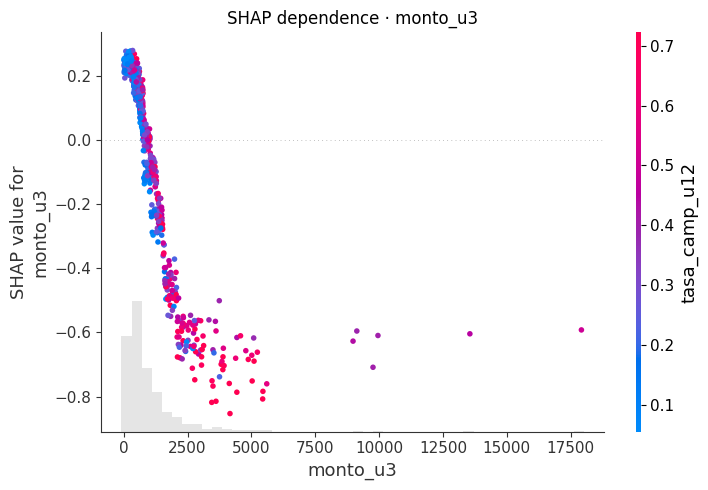

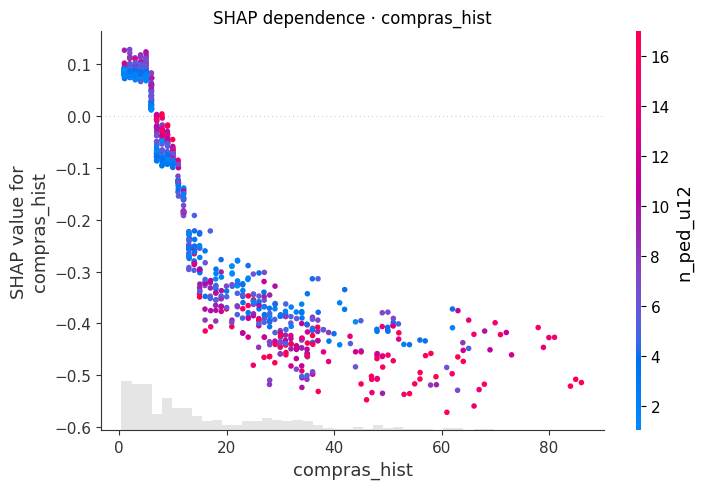

In [5]:
mean_abs = np.abs(sv.values).mean(0)
top_feats = [FEATS[i] for i in np.argsort(-mean_abs)[:3]]
print("Top 3 por |SHAP| promedio:", top_feats)
for feat in top_feats:
    shap.plots.scatter(sv[:, feat], color=sv, show=False)
    plt.title(f"SHAP dependence · {feat}")
    plt.tight_layout(); plt.show()

## C · Explicaciones locales (casos individuales)

`waterfall` descompone una predicción concreta: desde el valor base hasta la
predicción final, qué variable la empujó hacia churn y cuánto. Mostramos la
vendedora **de mayor riesgo** y la **de menor riesgo** del test. Esto es lo que
alimentaría un mensaje de retención personalizado.

Mayor riesgo: p(churn)=0.892 | real=1


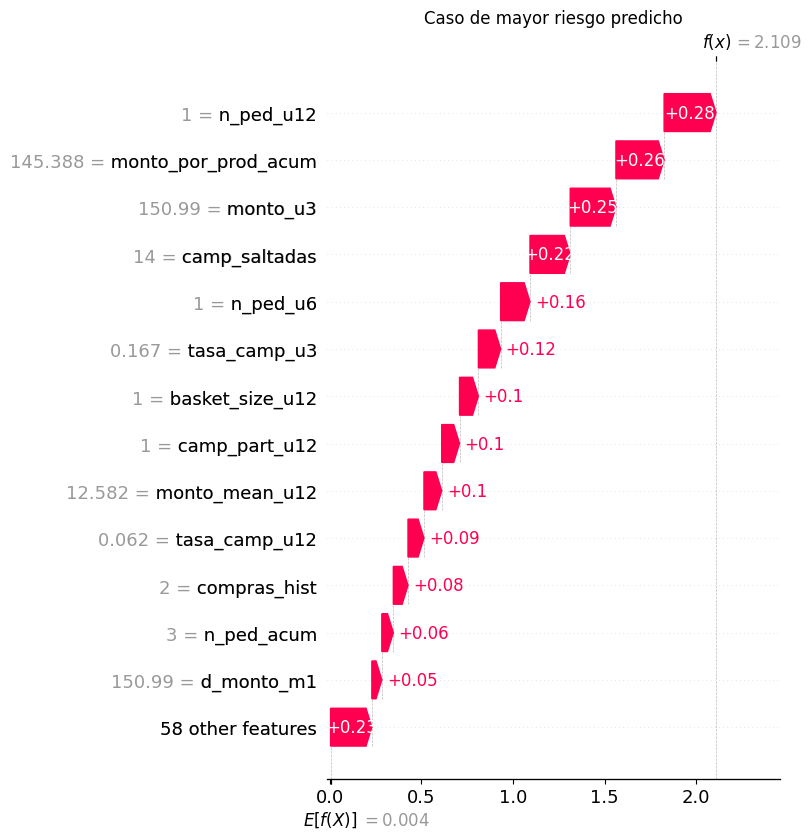

In [6]:
order = np.argsort(-p_test)
hi, lo = order[0], order[-1]
print(f"Mayor riesgo: p(churn)={p_test[hi]:.3f} | real={int(y_test[hi])}")
shap.plots.waterfall(sv[hi], max_display=14, show=False)
plt.title("Caso de mayor riesgo predicho"); plt.tight_layout(); plt.show()

Menor riesgo: p(churn)=0.017 | real=0


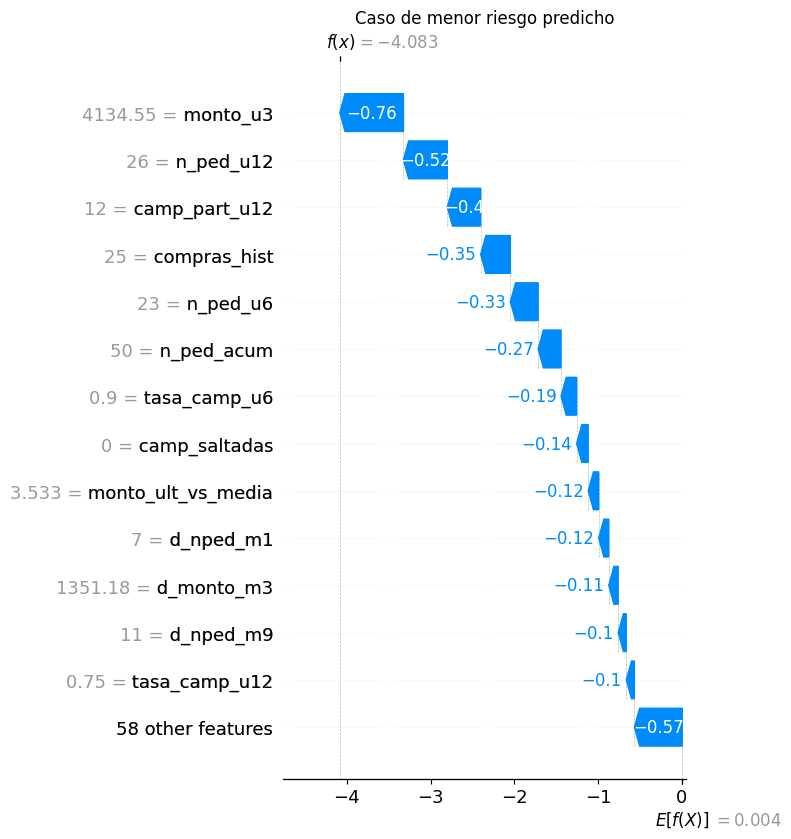

In [7]:
print(f"Menor riesgo: p(churn)={p_test[lo]:.3f} | real={int(y_test[lo])}")
shap.plots.waterfall(sv[lo], max_display=14, show=False)
plt.title("Caso de menor riesgo predicho"); plt.tight_layout(); plt.show()

## D · Síntesis

_(Completar tras ejecutar.)_

- Confirmar que la **dirección** de los efectos tiene sentido de negocio (p. ej.
  mayor `meses_desde_compra_previa` → más churn; mayor intensidad reciente → menos).
- Contrastar el ranking SHAP con el de `01_feature_importance.ipynb`: si coinciden,
  el modelo se apoya en señal interpretable y estable.
- Las explicaciones locales habilitan **acción**: para cada vendedora en riesgo, las
  variables con mayor aporte positivo indican el *porqué* y orientan el mensaje.

**Siguiente**: `03_utilidad_modelo.ipynb` traduce estas probabilidades en valor
operativo (a quién contactar, con qué retorno).